# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [3]:
# TODO
print("kích thước dữ liệu:", df.shape)
print()
print("tên các cột dữ liệu:", df.columns)
print()
print("kiểu dữ liệu của các cột:", df.dtypes)
print()
df.info()

kích thước dữ liệu: (541909, 8)

tên các cột dữ liệu: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

kiểu dữ liệu của các cột: InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 

## A.2. Missing values & Duplicate data

In [ ]:
# TODO
missing_values = df.isnull().sum()
print("Missing values:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "không có cột dữ liệu nào bị thiếu")
print()
print("Số lượng dòng trùng lặp:", df.duplicated().sum())


Missing values:
Description      1454
CustomerID     135080
dtype: int64

Số lượng cột trùng lặp: 5268


## A.3. Invalid values

In [ ]:
# TODO
print("Quantity <= 0:", (df['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (df['UnitPrice'] <= 0).sum())
print()
print("=> Dữ liệu chưa sạch: có 10.624 dòng số lượng <= 0 và 2517 dòng đơn giá <= 0")

Quantity <= 0: 10624
UnitPrice <= 0: 2517

=> Dữ liệu chưa sạch: có 10.624 dòng số lượng <= 0 (đơn hủy/hoàn trả) và 2 dòng đơn giá bị âm, cần phải lọc bỏ trước khi phân tích.


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [18]:
# TODO
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print("Số dòng còn lại sau khi làm sạch:", df.shape[0])
df['Sales'] = df['Quantity'] * df['UnitPrice']
df.head(5)

Số dòng còn lại sau khi làm sạch: 530104


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [19]:
# TODO
for col in ['Quantity', 'UnitPrice', 'Sales']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()
print("Mode country:", df['Country'].mode()[0])

Quantity: Mean=10.54, Median=3.00, Mode=1.00
UnitPrice: Mean=3.91, Median=2.08, Mode=1.25
Sales: Mean=20.12, Median=9.90, Mode=15.00

Mode country: United Kingdom


## Group 2 — Dispersion

In [20]:
# TODO
for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df[col]
    range_ = s.max()-s.min()
    std_ = s.std()
    q1,q3 = s.quantile([0.25,0.75]); iqr = q3-q1
    cv = std_/s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- Quantity ---
Range=80994.00, Std=155.52, IQR=9.00, CV=14.75
--- UnitPrice ---
Range=13541.33, Std=35.92, IQR=2.88, CV=9.19
--- Sales ---
Range=168469.60, Std=270.36, IQR=13.95, CV=13.44


## Group 3 — Location and Shape

--- Quantity ---
P25=1.00, P50=3.00, P75=10.00
Skewness=471.73, Kurtosis=236460.11
--- UnitPrice ---
P25=1.25, P50=2.08, P75=4.13
Skewness=206.09, Kurtosis=62482.55
--- Sales ---
P25=3.75, P50=9.90, P75=17.70
Skewness=506.70, Kurtosis=297648.85


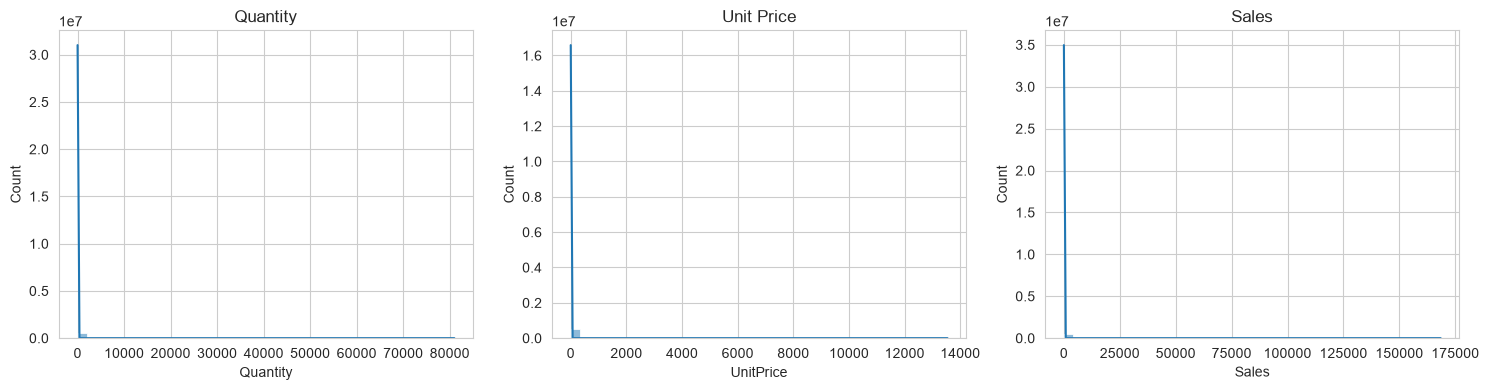

In [ ]:
# TODO
for col in ['Quantity', 'UnitPrice', 'Sales']:
    s = df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig,axes = plt.subplots(1,3,figsize=(15,4))
sns.histplot(df['Quantity'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('Quantity')
sns.histplot(df['UnitPrice'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('Unit Price')
sns.histplot(df['Sales'],bins=40,kde=True,ax=axes[2]); axes[2].set_title('Sales')
plt.tight_layout(); plt.show()


Nhận xét: Cả 3 biến (Quantity, UnitPrice, Sales) đều có độ lệch phải và Kurtosis cao đến mức cực đoan. Điều này phản ánh thực tế của ngành bán lẻ: 99% là các đơn hàng bán lẻ giá trị thấp, nhưng thỉnh thoảng xuất hiện các đơn hàng bán sỉ/bán buôn với số lượng và giá trị khổng lồ, tạo ra các outliers kéo giãn toàn bộ biểu đồ.

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

Country
United Kingdom    9025222.0
Netherlands        285446.0
EIRE               283454.0
Germany            228867.0
France             209715.0
Name: Sales, dtype: float64

=> United Kingdom đóng góp 84.6% tổng doanh thu.


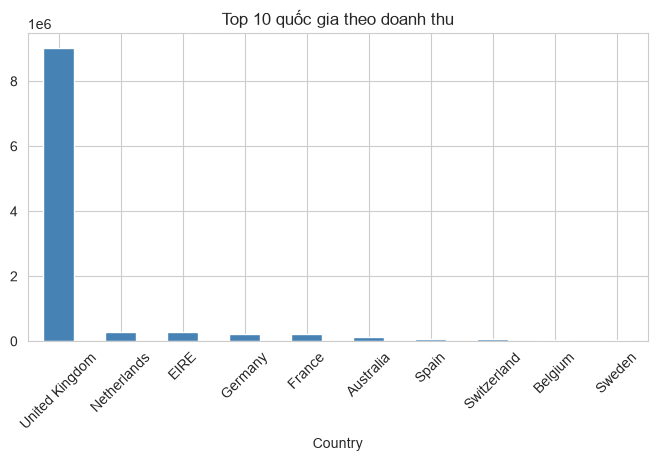

In [23]:
# TODO
Sales_by_country = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
top_country = Sales_by_country.index[0]
top_sales = Sales_by_country.iloc[0] / Sales_by_country.sum() * 100

print(Sales_by_country.head(5).round(0))
print(f"\n=> {top_country} đóng góp {top_sales:.1f}% tổng doanh thu.")

fig,ax=plt.subplots(figsize=(8,4))
Sales_by_country.head(10).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Top 10 quốc gia theo doanh thu'); plt.xticks(rotation=45); plt.show()


Insight: Doanh thu chỉ tập trung vào thị trường United Kingdom — đây là rủi ro tập trung cần lưu ý: nếu thị trường này gặp vấn đề, ảnh hưởng đến tổng doanh thu công ty sẽ rất lớn.

## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

Description
DOTCOM POSTAGE                        206249.0
REGENCY CAKESTAND 3 TIER              174485.0
PAPER CRAFT , LITTLE BIRDIE           168470.0
WHITE HANGING HEART T-LIGHT HOLDER    106293.0
PARTY BUNTING                          99504.0
Name: Sales, dtype: float64


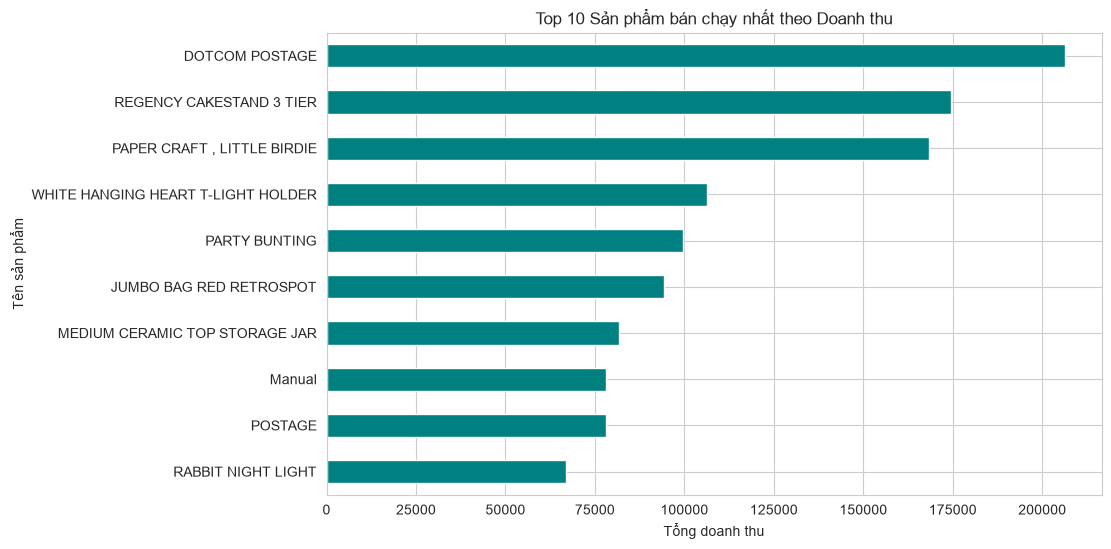

In [26]:
# TODO
top_products = df.groupby('Description')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products.head(5).round(0))

fig, ax = plt.subplots(figsize=(10, 6))
top_products.head(10).plot(kind='barh', color='teal', ax=ax)

ax.set_title('Top 10 Sản phẩm bán chạy nhất theo Doanh thu')
ax.set_xlabel('Tổng doanh thu')
ax.set_ylabel('Tên sản phẩm')
ax.invert_yaxis()
plt.show()

Insight: Sản phẩm mang lại doanh thu cao nhất cho cửa hàng là DOTCOM POSTAGE, vượt trội hơn hẳn so với các mặt hàng khác trong top 10. Điều này cho thấy cửa hàng nên tập trung duy trì nguồn hàng và đẩy mạnh marketing cho nhóm sản phẩm chủ lực này.

## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

YearMonth
2010-12     823746.0
2011-01     691365.0
2011-02     523632.0
2011-03     717639.0
2011-04     537809.0
2011-05     770536.0
2011-06     761740.0
2011-07     719221.0
2011-08     759138.0
2011-09    1058590.0
2011-10    1154979.0
2011-11    1509496.0
2011-12     638793.0
Freq: M, Name: Sales, dtype: float64


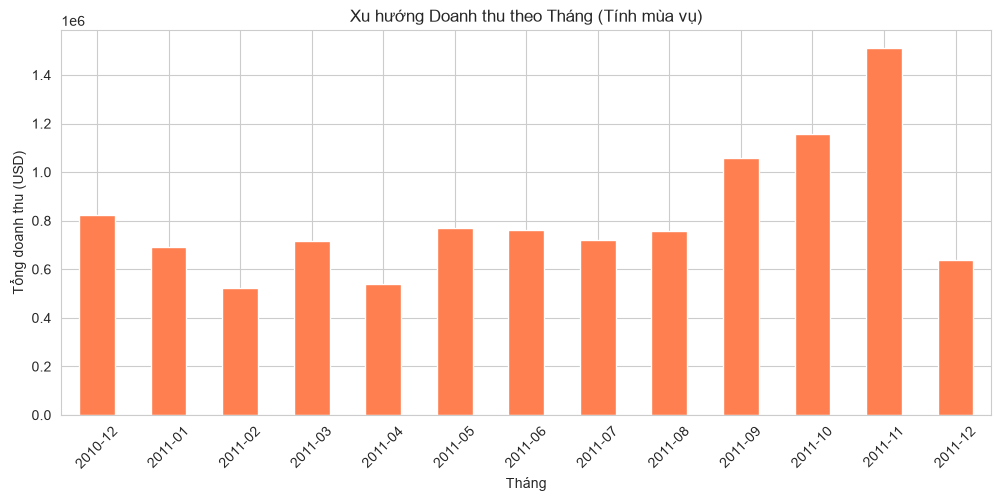

In [29]:
# TODO
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
sales_by_month = df.groupby('YearMonth')['Sales'].sum()
print(sales_by_month.round(0))

fig, ax = plt.subplots(figsize=(12, 5))
sales_by_month.plot(kind='bar', color='coral', ax=ax)

ax.set_title('Xu hướng Doanh thu theo Tháng (Tính mùa vụ)')
ax.set_xlabel('Tháng')
ax.set_ylabel('Tổng doanh thu (USD)')
plt.xticks(rotation=45)
plt.show()

Insight: Doanh thu có tính mùa vụ rõ rệt, duy trì ổn định ở mức trung bình trong hầu hết các tháng nhưng tăng vọt mạnh mẽ vào quý 4 (đỉnh điểm là tháng 11) do nhu cầu mua sắm cuối năm, trước khi sụt giảm vào tháng 12.

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

Country
Singapore      3039.90
Netherlands    3036.66
Australia      2430.20
Japan          1969.28
Lebanon        1693.88
Name: Sales, dtype: float64


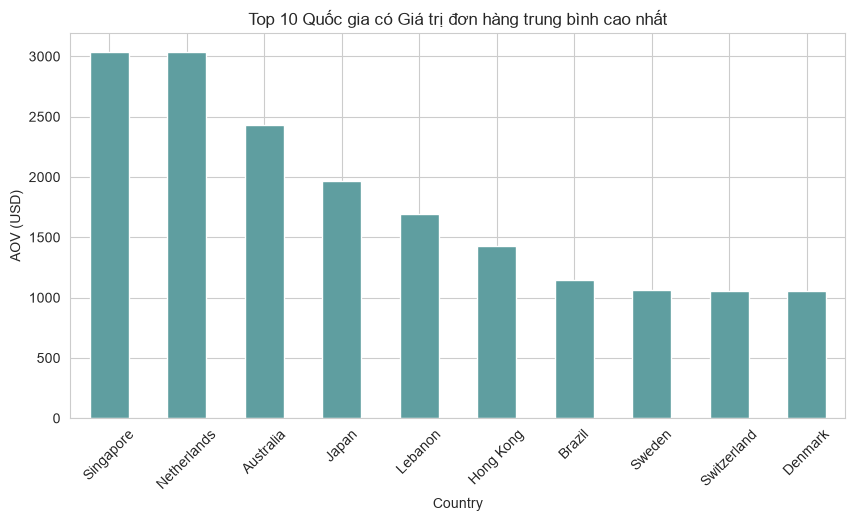

In [31]:
# TODO
order_values = df.groupby(['Country', 'InvoiceNo'])['Sales'].sum().reset_index()
aov_by_country = order_values.groupby('Country')['Sales'].mean().sort_values(ascending=False)
print(aov_by_country.head(5).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
aov_by_country.head(10).plot(kind='bar', color='cadetblue', ax=ax)
ax.set_title('Top 10 Quốc gia có Giá trị đơn hàng trung bình cao nhất')
ax.set_ylabel('AOV (USD)')
plt.xticks(rotation=45)
plt.show()

Insight: Singapore và Netherlands là hai quốc gia có giá trị đơn hàng trung bình cao nhất, đều đạt mức trên 3.000 USD.

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

Country
USA               38.49
Czech Republic    16.67
Malta             11.81
Japan             10.34
Saudi Arabia      10.00
Name: Is_Cancelled, dtype: float64


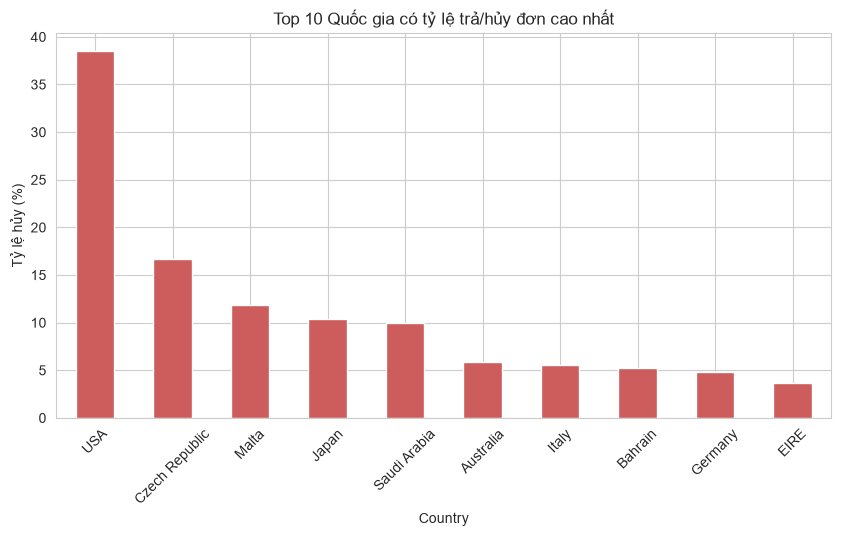

In [39]:
# TODO
csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'
df_raw = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')

df_raw['Is_Cancelled'] = df_raw['Quantity'] <= 0

cancel_rate_by_country = (df_raw.groupby('Country')['Is_Cancelled'].mean()*100).sort_values(ascending=False)
print(cancel_rate_by_country.head(5).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
cancel_rate_by_country.head(10).plot(kind='bar', color='indianred', ax=ax)
ax.set_title('Top 10 Quốc gia có tỷ lệ trả/hủy đơn cao nhất')
ax.set_ylabel('Tỷ lệ hủy (%)')
plt.xticks(rotation=45)
plt.show()

USA có tỷ lệ trả/hủy đơn hàng cao nhất, lên tới gần 40%, cách biệt rất lớn so với quốc gia đứng thứ hai là Czech Republic (chỉ hơn 15%)

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

Insight: Dữ liệu E-commerce cho thấy một bức tranh đa dạng về hành vi mua sắm. Xét về tổng thể, United Kingdom chiếm ưu thế tuyệt đối về mặt doanh thu. Tuy nhiên, nếu xét về quy mô từng đơn hàng, Singapore và Netherlands lại là hai thị trường dẫn đầu với giá trị đơn hàng trung bình (AOV) vượt mốc 3.000 USD. Về xu hướng thời gian, doanh thu có sự biến động rõ rệt theo tháng, đạt đỉnh cao nhất vào tháng 11 trước khi sụt giảm mạnh vào tháng 12. Bên cạnh đó, chất lượng đơn hàng cũng là một vấn đề cần lưu ý khi USA ghi nhận tỷ lệ hủy đơn cao bất thường, xấp xỉ 40%, vượt xa tất cả các quốc gia còn lại. Nhìn chung, bộ dữ liệu cho thấy phần lớn các giao dịch là đơn lẻ với số lượng và giá trị thấp, nhưng lại bị kéo lệch mạnh bởi một số ít các đơn hàng bán sỉ khổng lồ.